Training Accuracy: 0.8233
Testing Accuracy: 0.8900


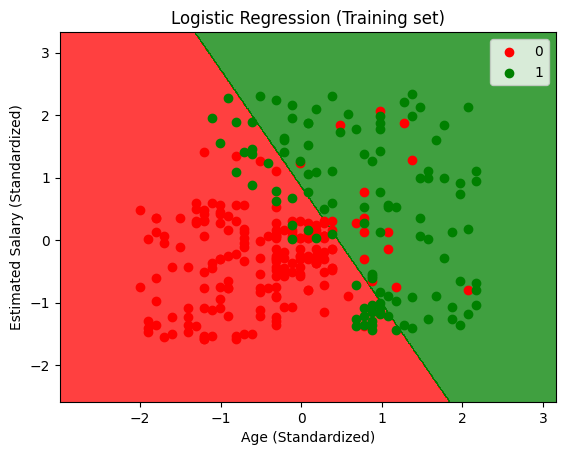


Prediction for Age 35, Salary $75k: 0
Probability of purchasing: 0.1945


C:\Users\Raja\Desktop\Project1\sara\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Social_Network_Ads.csv")

X = df[["Age", "EstimatedSalary"]]
y = df["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

train_acc = classifier.score(X_train, y_train)
test_acc = classifier.score(X_test, y_test)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")

X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01),
)
plt.contourf(
    X1,
    X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(("red", "green")),
)
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        color=ListedColormap(("red", "green"))(i),
        label=j,
    )
plt.title("Logistic Regression (Training set)")
plt.xlabel("Age (Standardized)")
plt.ylabel("Estimated Salary (Standardized)")
plt.legend()
plt.show()

custom_user = [[35, 75000]]
custom_user_scaled = scaler.transform(custom_user)
prediction = classifier.predict(custom_user_scaled)
probability = classifier.predict_proba(custom_user_scaled)
print(f"\nPrediction for Age 35, Salary $75k: {prediction[0]}")
print(f"Probability of purchasing: {probability[0][1]:.4f}")